# Fase 1 — Análise Exploratória de Dados

Este notebook apresenta a análise exploratória do dataset de predição de AVC (Stroke Prediction Dataset). O objetivo é compreender a estrutura da base, a distribuição das variáveis, a presença de dados faltantes, possíveis outliers e relações entre os atributos dos pacientes e a variável-alvo `stroke`.

A variável `stroke` indica se o paciente teve AVC:
- 0 = não teve AVC
- 1 = teve AVC

In [ ]:
!pip install kagglehub[pandas-datasets]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from kagglehub import KaggleDatasetAdapter

In [ ]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)
print("Arquivos encontrados:", os.listdir(path))

100%|██████████| 67.4k/67.4k [00:00<00:00, 44.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/stroke-prediction-dataset/versions/1
Arquivos encontrados: ['healthcare-dataset-stroke-data.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, "healthcare-dataset-stroke-data.csv"))

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [ ]:
df.shape
print(f"A base possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

A base possui 5110 linhas e 12 colunas.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
df['stroke'].value_counts(normalize=True) * 100

,proportion
stroke,
0,95.127202
1,4.872798


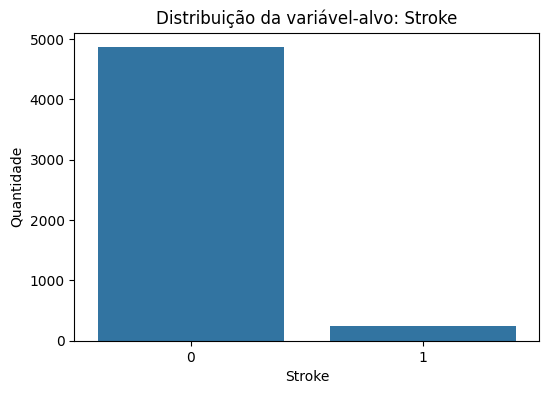

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='stroke')
plt.title('Distribuição da variável-alvo: Stroke')
plt.xlabel('Stroke')
plt.ylabel('Quantidade')
plt.show()

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
id,0.000000
gender,0.000000
age,0.000000
hypertension,0.000000
heart_disease,0.000000
ever_married,0.000000
work_type,0.000000
Residence_type,0.000000
avg_glucose_level,0.000000
bmi,3.933464


In [ ]:
df['smoking_status'].value_counts()

,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


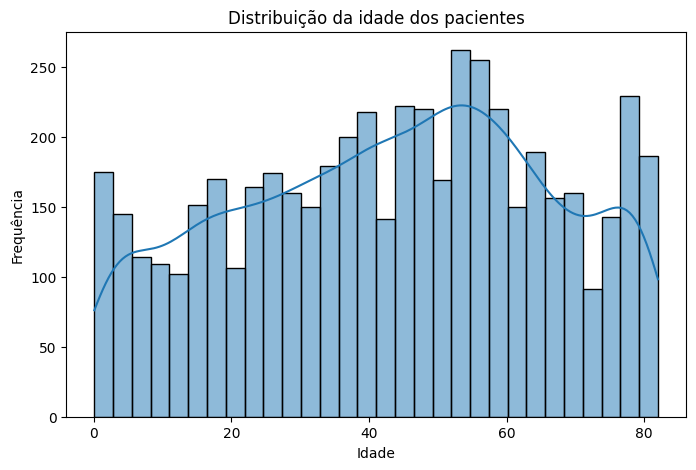

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', bins=30, kde=True)
plt.title('Distribuição da idade dos pacientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

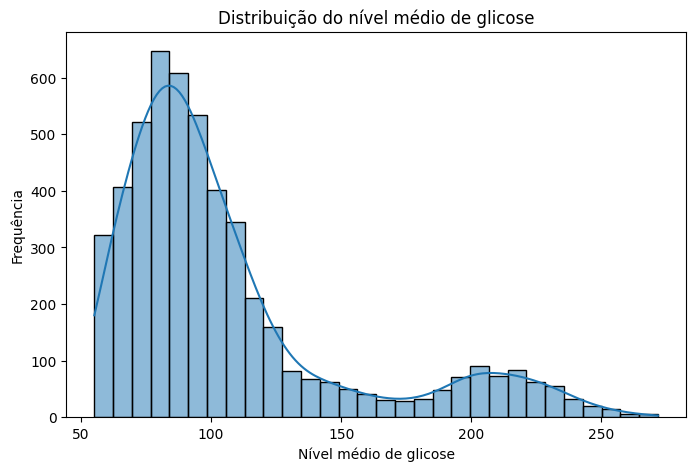

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='avg_glucose_level', bins=30, kde=True)
plt.title('Distribuição do nível médio de glicose')
plt.xlabel('Nível médio de glicose')
plt.ylabel('Frequência')
plt.show()

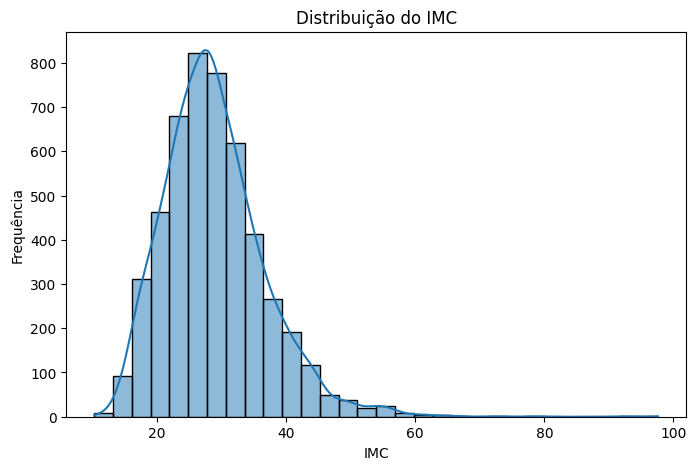

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='bmi', bins=30, kde=True)
plt.title('Distribuição do IMC')
plt.xlabel('IMC')
plt.ylabel('Frequência')
plt.show()

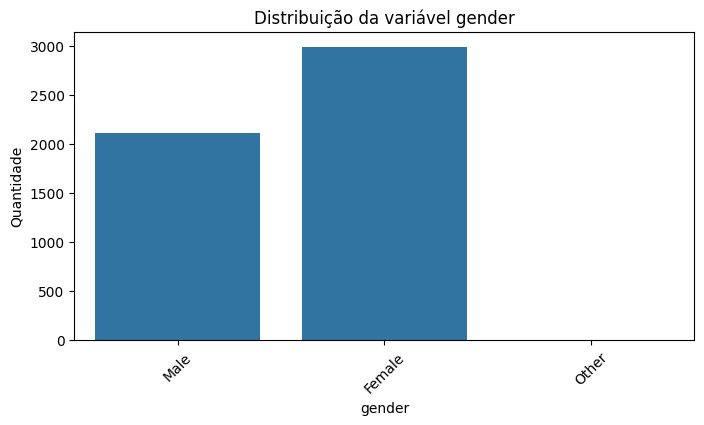

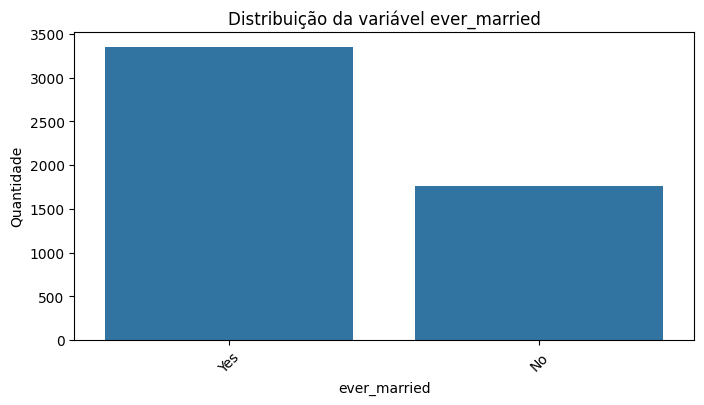

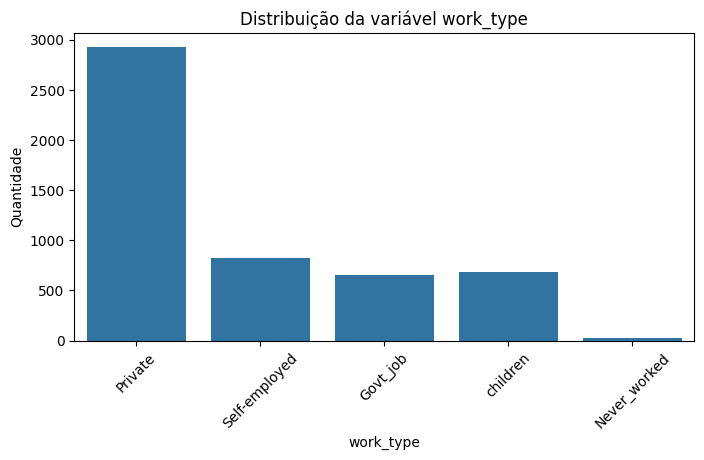

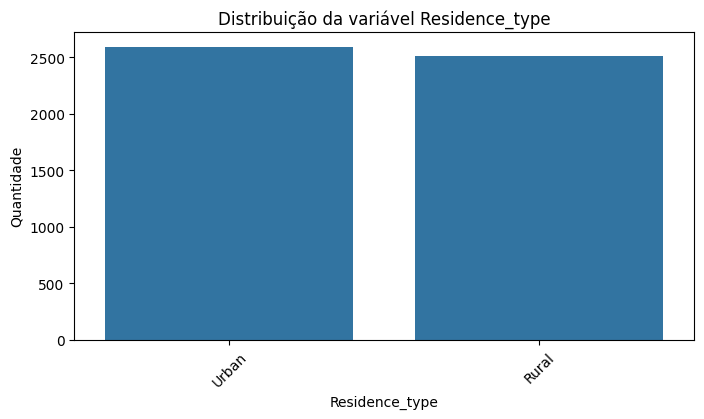

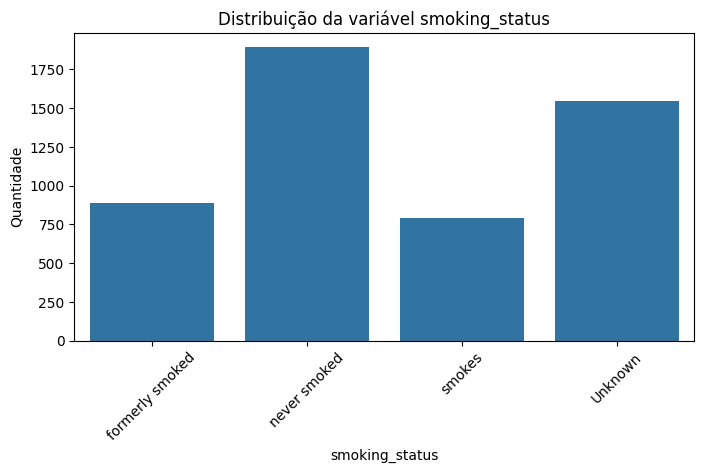

In [ ]:
colunas_categoricas = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for coluna in colunas_categoricas:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=coluna)
    plt.title(f'Distribuição da variável {coluna}')
    plt.xlabel(coluna)
    plt.ylabel('Quantidade')
    plt.xticks(rotation=45)
    plt.show()

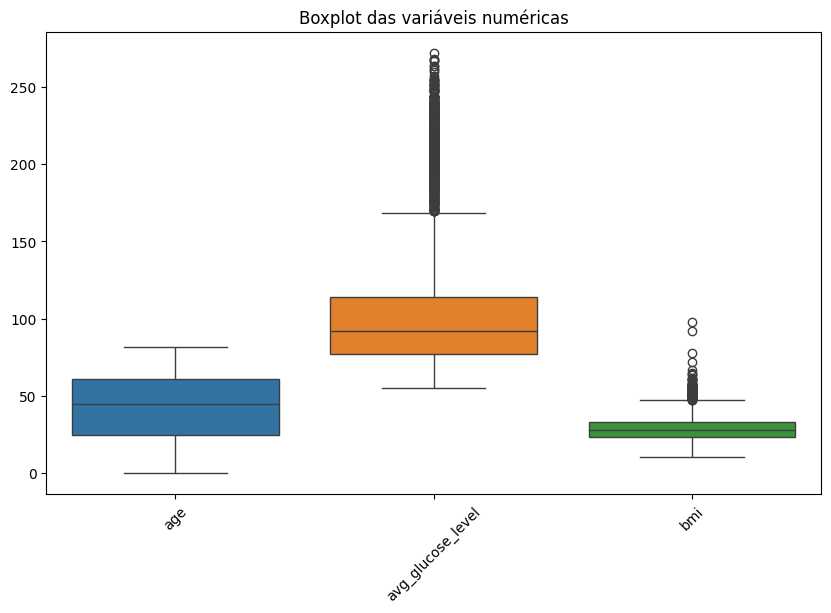

In [ ]:
colunas_numericas = ['age', 'avg_glucose_level', 'bmi']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[colunas_numericas])
plt.title('Boxplot das variáveis numéricas')
plt.xticks(rotation=45)
plt.show()

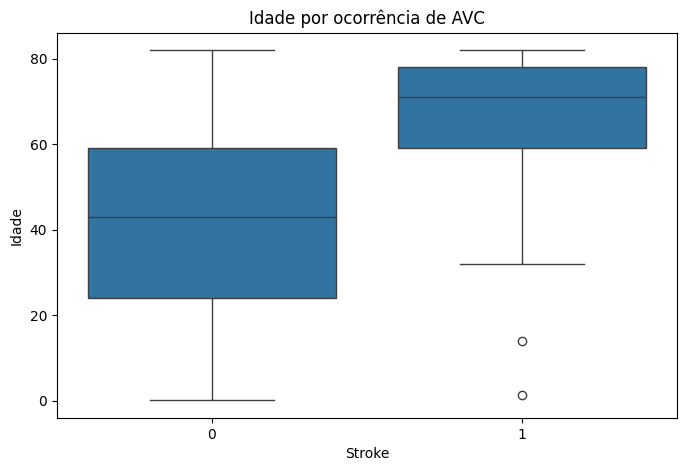

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='stroke', y='age')
plt.title('Idade por ocorrência de AVC')
plt.xlabel('Stroke')
plt.ylabel('Idade')
plt.show()

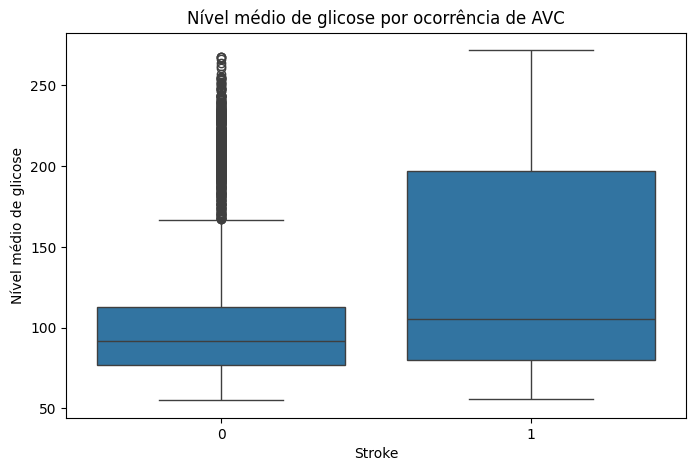

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='stroke', y='avg_glucose_level')
plt.title('Nível médio de glicose por ocorrência de AVC')
plt.xlabel('Stroke')
plt.ylabel('Nível médio de glicose')
plt.show()

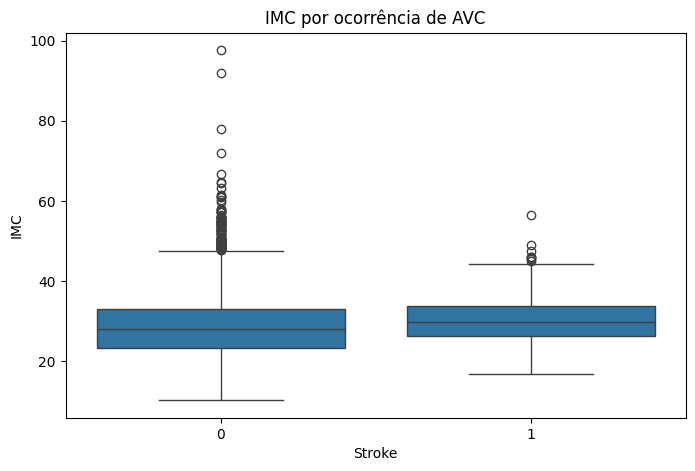

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='stroke', y='bmi')
plt.title('IMC por ocorrência de AVC')
plt.xlabel('Stroke')
plt.ylabel('IMC')
plt.show()

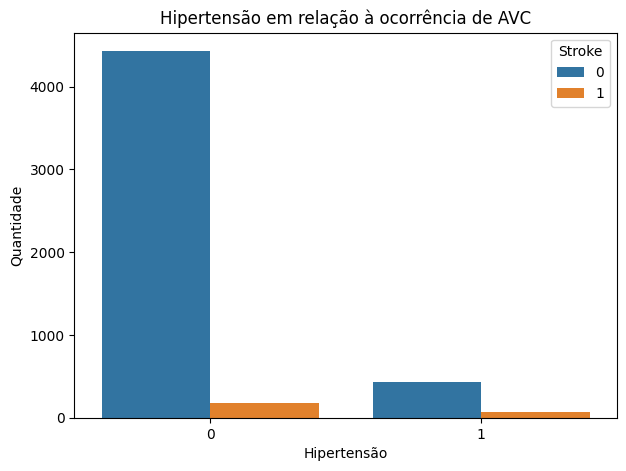

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='hypertension', hue='stroke')
plt.title('Hipertensão em relação à ocorrência de AVC')
plt.xlabel('Hipertensão')
plt.ylabel('Quantidade')
plt.legend(title='Stroke')
plt.show()

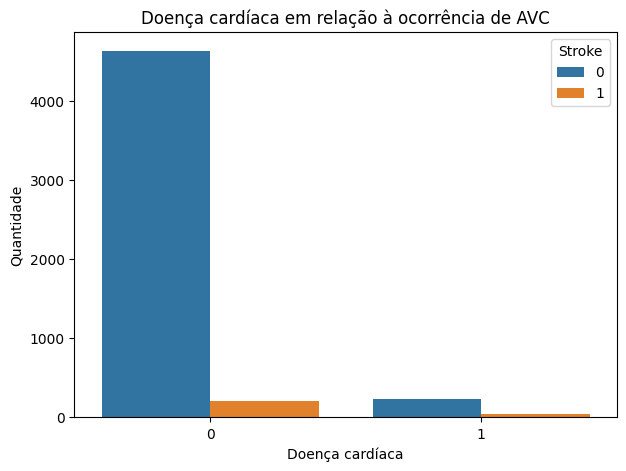

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='heart_disease', hue='stroke')
plt.title('Doença cardíaca em relação à ocorrência de AVC')
plt.xlabel('Doença cardíaca')
plt.ylabel('Quantidade')
plt.legend(title='Stroke')
plt.show()

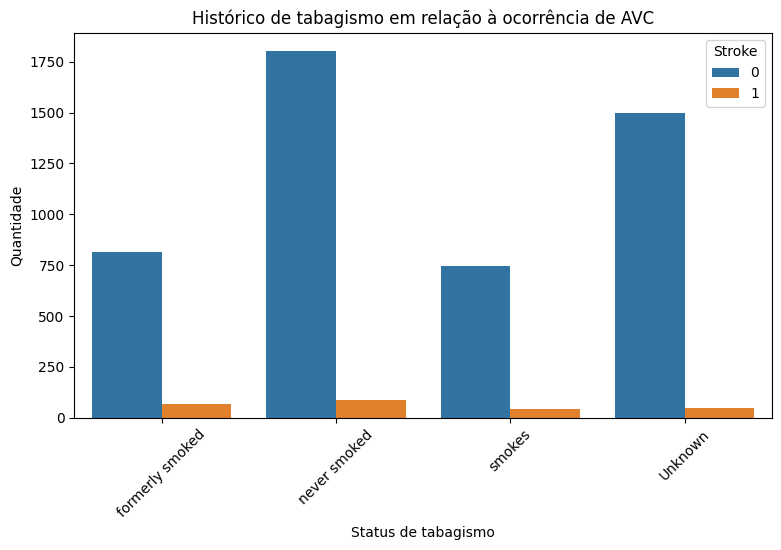

In [ ]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='smoking_status', hue='stroke')
plt.title('Histórico de tabagismo em relação à ocorrência de AVC')
plt.xlabel('Status de tabagismo')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.legend(title='Stroke')
plt.show()

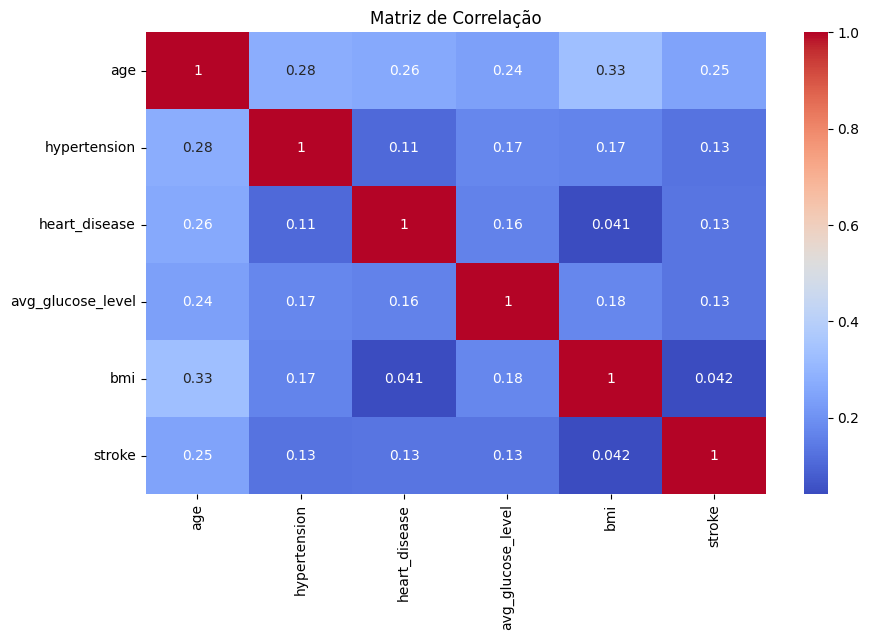

In [ ]:
correlacao = df[['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']].corr()

correlacao
plt.figure(figsize=(10, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()


## Análise Fase 1 — Análise Exploratória de Dados


Inicialmente, o dataset foi carregado a partir do Kaggle e foram realizadas verificações básicas com `head()`, `tail()`, `shape`, `info()`, `describe()` e `columns`. Essas etapas permitiram observar a organização geral da base, a quantidade de registros e colunas, os tipos de dados presentes e as principais estatísticas descritivas das variáveis numéricas. Também foi possível identificar que a coluna `id` funciona apenas como identificador único dos pacientes, não representando uma variável clínica relevante para análise de risco.

Em seguida, foi analisada a variável-alvo `stroke`, em que `0` representa pacientes que não tiveram AVC e `1` representa pacientes que tiveram AVC. A contagem e o gráfico de distribuição mostraram que a base é fortemente desbalanceada, pois existe uma quantidade muito maior de pacientes sem AVC do que de pacientes com AVC. Esse é um ponto importante para as próximas fases do projeto, pois modelos treinados com bases desbalanceadas podem apresentar alta acurácia apenas por preverem a classe majoritária, sem necessariamente identificarem bem os pacientes com AVC.

Na etapa de identificação de dados faltantes, foi utilizada a função `isnull().sum()` para verificar a quantidade de valores ausentes em cada coluna. O resultado mostrou que apenas a variável `bmi`, referente ao índice de massa corporal, possui valores nulos, totalizando 201 registros ausentes. Também foi calculado o percentual de valores faltantes, permitindo compreender melhor o impacto dessa ausência na base. Esse problema não foi tratado nesta fase, pois a Fase 1 tem caráter exploratório, mas deverá ser resolvido posteriormente no pipeline de preparação dos dados, por meio de estratégias como imputação pela média, mediana ou outro método adequado.

Além dos valores nulos, também foi analisada a variável `smoking_status`. Essa coluna não apresenta valores nulos formais, mas possui a categoria `Unknown`, que significa que a informação sobre o histórico de tabagismo do paciente está indisponível. Portanto, mesmo não sendo registrada como nula pelo Pandas, essa categoria representa um problema de completude da informação e deverá ser considerada nas próximas etapas do projeto.

Na análise univariada, foram observadas individualmente variáveis numéricas como `age`, `avg_glucose_level` e `bmi`, por meio de histogramas. Esses gráficos permitiram visualizar a distribuição da idade dos pacientes, do nível médio de glicose no sangue e do índice de massa corporal. A idade é uma variável importante porque pode estar relacionada ao aumento do risco de AVC. O nível médio de glicose também é relevante por indicar aspectos metabólicos dos pacientes, enquanto o IMC auxilia na compreensão do perfil corporal da população analisada.

Também foram analisadas variáveis categóricas como `gender`, `ever_married`, `work_type`, `Residence_type` e `smoking_status`, utilizando gráficos de contagem. Essa análise permitiu compreender o perfil dos pacientes quanto ao gênero, estado civil, tipo de trabalho, tipo de residência e histórico de tabagismo. Essas variáveis podem contribuir para a compreensão do contexto demográfico e social dos pacientes presentes na base.

Para a identificação de possíveis outliers, foram utilizados boxplots das variáveis numéricas `age`, `avg_glucose_level` e `bmi`. Essa análise indicou a presença de possíveis valores extremos, principalmente em variáveis como nível médio de glicose e IMC. Esses valores não devem ser removidos automaticamente nesta fase, pois podem representar casos reais e clinicamente relevantes. No entanto, eles precisam ser analisados com cuidado na próxima etapa, antes da construção do modelo.

Na análise bivariada, foram comparadas algumas variáveis com a ocorrência de AVC. A idade foi analisada em relação à variável `stroke`, permitindo observar se pacientes que tiveram AVC apresentam uma distribuição etária diferente dos pacientes que não tiveram. Também foram analisados o nível médio de glicose e o IMC em relação ao AVC, buscando identificar possíveis diferenças entre os grupos. Essas comparações ajudam a levantar hipóteses sobre quais variáveis podem ter maior relação com a ocorrência de AVC.

Além disso, foram analisadas variáveis clínicas binárias, como `hypertension` e `heart_disease`, em relação à variável `stroke`. Os gráficos de contagem permitiram observar a distribuição dos casos de AVC entre pacientes com e sem hipertensão, bem como entre pacientes com e sem doença cardíaca. Essas variáveis são importantes porque representam condições de saúde que podem estar associadas ao risco de AVC.

Também foi realizada a análise do histórico de tabagismo em relação à ocorrência de AVC, utilizando a variável `smoking_status`. Essa análise permitiu observar como os casos de AVC estão distribuídos entre pacientes que nunca fumaram, fumam, já fumaram ou possuem informação desconhecida. A presença da categoria `Unknown` reforça a necessidade de atenção na etapa futura de tratamento dos dados.

Por fim, foi construída uma matriz de correlação considerando variáveis numéricas e binárias como `age`, `hypertension`, `heart_disease`, `avg_glucose_level`, `bmi` e `stroke`. Essa matriz permitiu observar o grau de associação entre as variáveis e identificar quais atributos apresentam maior relação linear com a variável-alvo. Embora correlação não indique causalidade, essa análise ajuda a orientar a seleção e o entendimento das variáveis que poderão ser utilizadas nas próximas fases.

Foram identificados pontos importantes, como o forte desbalanceamento da variável-alvo, a existência de valores nulos na coluna `bmi`, a presença da categoria `Unknown` em `smoking_status`, outliers em variáveis numéricas.

Nessa próxima etapa, será necessário tratar valores nulos, avaliar a melhor estratégia para a categoria `Unknown`, codificar variáveis categóricas, escalonar variáveis numéricas e aplicar técnicas de balanceamento para lidar com a classe minoritária.